In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
deep = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo.fits'))
print(len(deep), len(np.unique(deep['TARGETID'])))

mask = deep['subset']=='deep'
print(np.sum(mask))
mask &= deep['TARGETS']=='QSO+LRG'
print(np.sum(mask))

deep = deep[mask]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = deep['R_DEPTH_EBVAIR']>min_depth
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

print(len(deep), len(np.unique(deep['TARGETID'])))

deep.rename_columns(['B_DEPTH', 'R_DEPTH', 'Z_DEPTH', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR'],
    ['B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep'])

79651 14100
14530
10113
10113 10113
FIBERSTATUS 8364 1749 0.1729457134381489
No data 8364 0 0.0
5942 2422 0.7104256336681014
5942 5942


In [4]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/LRG/alltiles_LRGzinfo_1exp.fits'))
print(len(zbest), len(np.unique(zbest['TARGETID'])))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
mask &= np.in1d(zbest['TILEID'], np.unique(deep['TILEID']))
zbest = zbest[mask]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

zbest = join(zbest, deep[['TARGETID', 'B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep']], keys='TARGETID')

tileid_list = np.unique(zbest['TILEID'])

198699 14100
80626 5942


In [5]:
zbest[:1]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,DELTA_X,DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,elgqso_weight,FIELD,TARGETS,SPECMODEL_SKY_RMAG_AB,HASGFA,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,BITPSFFN,BITFRAMEFN,BITSKYFN,BITSFRAMEFN,BITFLUXCALIBFN,BITCFRAMEFN,TGT,SKY,STD,WD,LRG,ELG,QSO,BGS,MWS,TILERA,TILEDEC,EXPTIME,MJDOBS,GFA_AIRMASS,GFA_MOON_ILLUMINATION,GFA_MOON_ZD_DEG,GFA_MOON_SEP_DEG,GFA_TRANSPARENCY,GFA_FWHM_ASEC,GFA_SKY_MAG_AB,GFA_FIBER_FRACFLUX,GFA_FIBER_FRACFLUX_ELG,GFA_TRANSPFRAC,GFA_MAXCONTRAST,GFA_MINCONTRAST,GFA_KTERM,GFA_RADPROF_FWHM_ASEC,Z_deep,ZWARN_deep,DELTACHI2_deep,B_DEPTH_deep,R_DEPTH_deep,Z_DEPTH_deep,B_DEPTH_EBVAIR_deep,R_DEPTH_EBVAIR_deep,Z_DEPTH_EBVAIR_deep
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,float64,float64,float64,float64,float64,str10,str7,float32,bool,float32,float32,float32,float32,float32,float32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,int64,float64,float64,float64,float64,float64,float64,float64
39627805352265275,8915.699081657454,473.33689803974954 .. 4.099613333095931,0.38714468894833365,0.0001238143655835395,0,7826,GALAXY,,10,776.775258326903,0,1,1,485,1485,666,0,149.31702367611464,0.8448453052364348,0.0,0.0,2020.9487,5400.0,1152921504707510369,1,TGT,203.78088,-344.5449,0,3200,0.6554448879017679,5,DEV,2.8328052,15.289917,34.912575,854.51764,249.38046,64.94606,0,,0.0,0.0,0.0,0.0,0.023,62.81794,38.44772,1.525466,8.233623,18.800426,1.5254711,8.233633,18.800453,0,4.0,0.51233107,0.121759854,-0.35520807,S,1152921504707510369,131074,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,203.715,-344.427,-0.005,-0.003,149.31704343778486,0.8448334601186536,20201215,68063,59199.50455879,80609,324.8830233514309,5901.6265869140625,32.82942450046539,41.46331238746643,1.0,COSMOS,QSO+LRG,21.316456,True,515.6,420.1,417.7,422.9307,370.56876,389.49176,1073741823,1073741823,1073741823,1073741823,1073741823,1073741823,4199,800,162,10,2125,1317,1341,395,207,150.12,2.206,900.0,59199.504,1.1619775,0.045501556,138.59363,137.41573,0.98538613,1.3731751,19.911888,0.41571525,0.32178935,0.40964004,6.8307137,4.9390993,0.114,1.4107234,0.38723480453295644,0,14951.379413604736,10984.599914550781,7969.700042724609,7215.700103759766,8965.964721679688,7011.713165283203,6717.894836425781


In [6]:
t = Table()
_, idx = np.unique(zbest['TARGETID'], return_index=True)
t['TILEID'], t['count_unique'] = np.unique(zbest['TILEID'][idx], return_counts=True)
t1 = Table()
t1['TILEID'], t1['count_repeat'] = np.unique(zbest['TILEID'], return_counts=True)
t = join(t, t1)
t['ratio'] = t['count_repeat']/t['count_unique']
t

TILEID,count_unique,count_repeat,ratio
int32,int64,int64,float64
80607,1582,27928,17.653603034134008
80609,1684,25260,15.0
80620,1434,17644,12.304044630404462
80622,1242,9794,7.885668276972625


80607 False 18


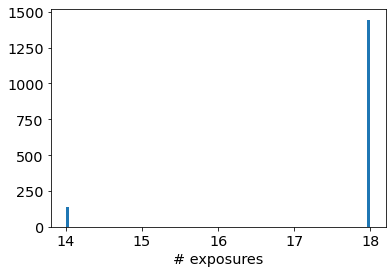

80609 True 15
80620 False 13


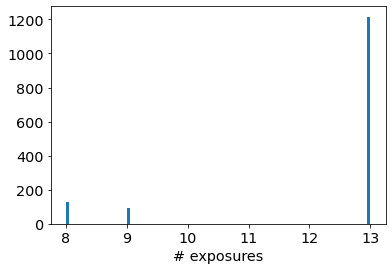

80622 False 8


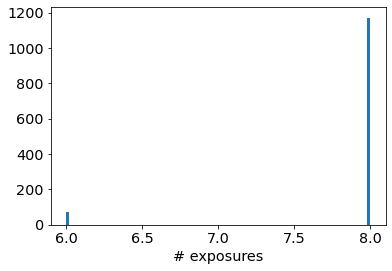

In [7]:
for tileid in tileid_list:
    mask = zbest['TILEID']==tileid
    t = Table()
    t['TARGETID'], t['count'] = np.unique(zbest['TARGETID'][mask], return_counts=True)
    print(tileid, np.all(t['count']== np.max(t['count'][0])), np.max(t['count'][0]))
    if not np.all(t['count']==t['count'][0]):
        plt.hist(t['count'], 100)
        plt.xlabel('# exposures')
        plt.show()

In [8]:
# stats = Table.read('/global/cfs/cdirs/desi/survey/observations/SV1/sv1-exposures.fits')
stats = Table.read('/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/sv1-exposures_20210210.fits')
print(len(stats))

mask = np.in1d(stats['EXPID'], np.unique(zbest['EXPID']))
stats = stats[mask]
print(len(stats))

stats['fail_frac_lrg_sv'] = -1.
stats['fail_frac_lrg_opt'] = -1.
stats['fail_frac_lrg_ir'] = -1.

stats['n_lrg_sv'] = -1
stats['n_lrg_opt'] = -1
stats['n_lrg_ir'] = -1

stats['deltachi2_ratio'] = -1.

mask_fiber = (zbest['FIBERSTATUS']==0) & (zbest['ZWARN'] & 2**9==0)

fail_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > fail_threshold
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0

for tileid in tileid_list:
    
    # print('Tile {}'.format(tileid))
        
    expid_list = np.array(np.unique(zbest['EXPID']))


    for expid in expid_list:
        
        stats_index = np.where(stats['EXPID']==expid)[0][0]
        
        mask_exp = mask_fiber & (zbest['EXPID']==expid)
        mask_exp_fail = mask_exp & mask_fail

        stats['fail_frac_lrg_sv'][stats_index] = np.sum(mask_exp_fail) / np.sum(mask_exp)
        stats['fail_frac_lrg_opt'][stats_index] = np.sum(mask_exp_fail & lrg_opt) / np.sum(mask_exp & lrg_opt)
        stats['fail_frac_lrg_ir'][stats_index] = np.sum(mask_exp_fail & lrg_ir) / np.sum(mask_exp & lrg_ir)        
        stats['n_lrg_sv'][stats_index] = np.sum(mask_exp)
        stats['n_lrg_opt'][stats_index] = np.sum(mask_exp & lrg_opt)
        stats['n_lrg_ir'][stats_index] = np.sum(mask_exp & lrg_ir)
        
        mask_deltachi2 = zbest['DELTACHI2_deep']>100. # quality cut
        stats['deltachi2_ratio'][stats_index] = np.median((zbest['DELTACHI2']/(zbest['DELTACHI2_deep']/zbest['R_DEPTH_EBVAIR_deep']*1000))[mask_exp & mask_deltachi2])

974
54


In [9]:
stats.write('/global/cscratch1/sd/rongpu/desi/sv1/single_exp_coadd_blanc/lrg_redshift_efficiency_new.fits', overwrite=True)

In [10]:
stats[:1]

NIGHT,EXPID,FIELD,TARGETS,OBSCONDITIONS,EBV,SPECMODEL_SKY_GMAG_AB,SPECMODEL_SKY_RMAG_AB,GFA_ORIGIN,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,BITPSFFN,BITFRAMEFN,BITSKYFN,BITSFRAMEFN,BITFLUXCALIBFN,BITCFRAMEFN,TGT,SKY,STD,WD,LRG,ELG,QSO,BGS,MWS,TILEID,TILERA,TILEDEC,EXPTIME,MJDOBS,GFA_AIRMASS,GFA_MOON_ILLUMINATION,GFA_MOON_ZD_DEG,GFA_MOON_SEP_DEG,GFA_TRANSPARENCY,GFA_FWHM_ASEC,GFA_SKY_MAG_AB,GFA_FIBER_FRACFLUX,GFA_FIBER_FRACFLUX_ELG,GFA_TRANSPFRAC,GFA_MAXCONTRAST,GFA_MINCONTRAST,GFA_KTERM,GFA_RADPROF_FWHM_ASEC,EPHEM_NOON,EPHEM_DUSK,EPHEM_DAWN,EPHEM_BRIGHTDUSK,EPHEM_BRIGHTDAWN,EPHEM_BRIGHTDUSK_LST,EPHEM_BRIGHTDAWN_LST,EPHEM_MOONRISE,EPHEM_MOONSET,EPHEM_MOON_ILLUM_FRAC,EPHEM_NEAREST_FULL_MOON,fail_frac_lrg_sv,fail_frac_lrg_opt,fail_frac_lrg_ir,n_lrg_sv,n_lrg_opt,n_lrg_ir,deltachi2_ratio
int64,int64,bytes30,bytes16,int64,float32,float32,float32,bytes13,float32,float32,float32,float32,float32,float32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64
20201214,67744,Lynx,QSO+LRG,1,0.053,22.650038,21.552229,matched_coadd,322.7,297.3,349.7,216.36797,228.97583,302.46777,1073741823,1073741823,1073741823,1073741823,1073741823,1073741823,4199,800,150,12,1922,1212,1684,380,208,80607,106.74,56.1,900.0,59198.266,1.2151204,0.005023045,160.37282,148.07368,0.9659074,1.6643472,20.543156,0.31220964,0.25188032,0.30156562,14.702887,10.021965,0.114,1.6531557,59197.791666666664,59198.066745730626,59198.54668876452,59198.05982057322,59198.553616188605,-5.896143626986145,172.35701092094754,59197.59470830986,59198.02745986081,0.005432771706774475,14.852906347514363,0.23227548953409857,0.06698564593301436,0.0702576112412178,1481,418,427,0.2570374935329328


In [11]:
# mask = stats['fail_frac_lrg_sv']!=-1
# print(np.sum(~mask))
# stats = stats[mask]

__Full depth range__

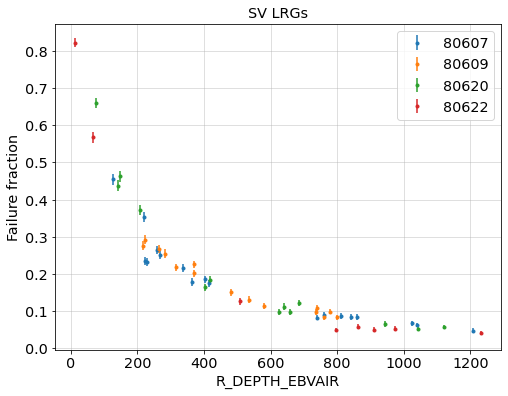

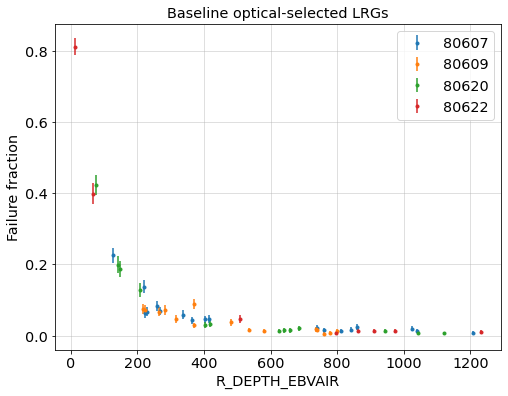

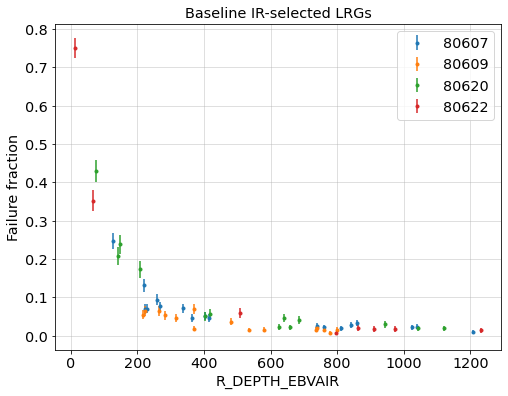

In [12]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid)
    n, p = stats['n_lrg_sv'][mask], stats['fail_frac_lrg_sv'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('R_DEPTH_EBVAIR')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('SV LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid)
    n, p = stats['n_lrg_opt'][mask], stats['fail_frac_lrg_opt'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('R_DEPTH_EBVAIR')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('Baseline optical-selected LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid)
    n, p = stats['n_lrg_ir'][mask], stats['fail_frac_lrg_ir'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('R_DEPTH_EBVAIR')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('Baseline IR-selected LRGs')
plt.show()

__Only exposures with R_DEPTH_EBVAIR>250__

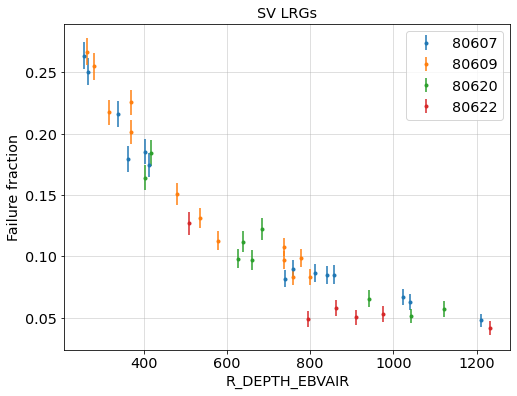

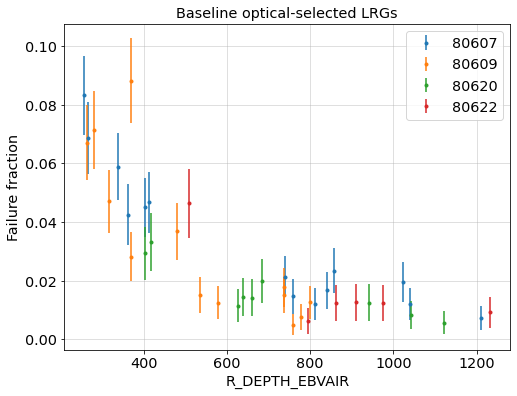

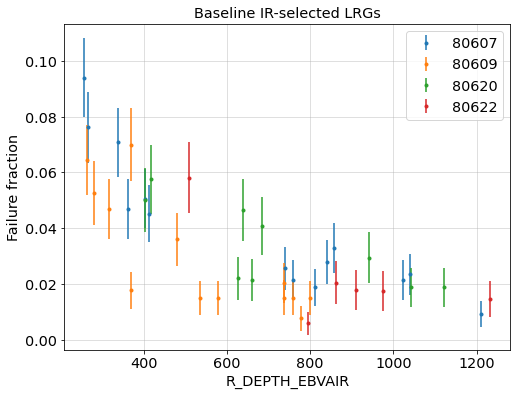

In [13]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
    n, p = stats['n_lrg_sv'][mask], stats['fail_frac_lrg_sv'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('R_DEPTH_EBVAIR')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('SV LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
    n, p = stats['n_lrg_opt'][mask], stats['fail_frac_lrg_opt'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('R_DEPTH_EBVAIR')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('Baseline optical-selected LRGs')
plt.show()

plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
    n, p = stats['n_lrg_ir'][mask], stats['fail_frac_lrg_ir'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.xlabel('R_DEPTH_EBVAIR')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('Baseline IR-selected LRGs')
plt.show()

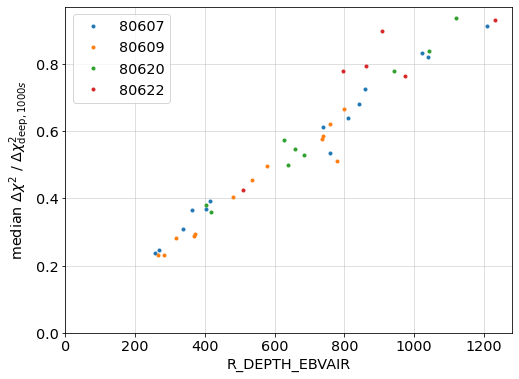

In [14]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
    plt.plot((stats['R_DEPTH_EBVAIR'])[mask], stats['deltachi2_ratio'][mask], '.', label=tileid)
plt.xlabel('R_DEPTH_EBVAIR')
plt.ylabel('median $\Delta\chi^2 \ / \ \Delta\chi_{\mathrm{deep},1000s}^2$')
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.grid(alpha=0.5)
plt.legend(loc='upper left')
plt.show()

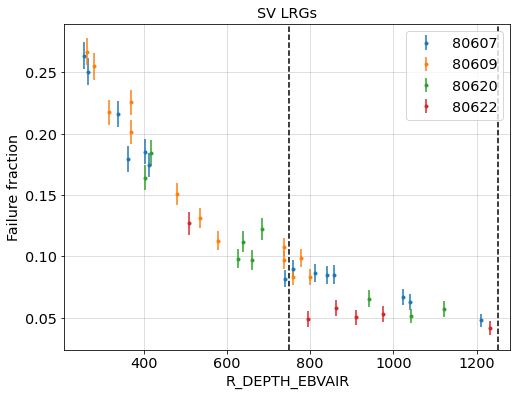

In [16]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
    n, p = stats['n_lrg_sv'][mask], stats['fail_frac_lrg_sv'][mask]
    p1 = np.maximum(p, 1/n)  # error floor
    errors = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], p, 
                 yerr=(np.clip(errors, None, p), errors),
                 fmt='.', label=tileid)
plt.axvline(750, ls='--', color='k')
plt.axvline(1250, ls='--', color='k')
plt.xlabel('R_DEPTH_EBVAIR')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('SV LRGs')
plt.show()

In [1]:
1

1